<img style="float: center;" src='https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_header.png' alt="stsci_logo" width="900px"/> 

# NIRISS SOSS Pipeline Notebook

**Authors**: R. Cooper, A. Carter, N. Espinoza, T. Baines<br>
**Last Updated**: April 17, 2026<br>
**Pipeline Version**: 2.0.0 (Build 12.3)

**Purpose**:<br>
This notebook provides a framework for processing Near-Infrared
Imager and Slitless Spectrograph (NIRISS) Single Object Slitless Spectrograph (SOSS) data through all
three James Webb Space Telescope (JWST) pipeline stages.  Data is assumed
to be located in one observation folder according to paths set up below.
It should not be necessary to edit any cells other than in the
[Configuration](#1.-Configuration) section unless modifying the standard
pipeline processing options.

**Data**:<br>
This notebook uses an example dataset from Early Release Observation (ER0) [Program
2734](https://www.stsci.edu/jwst/science-execution/program-information) (PI: K. Pontoppidan).
This program consists of time series observations (TSO) of confirmed exoplanets HAT-P-18b and WASP-96b,
intended to demonstrate the power and precision of the JWST TSO modes. In this notebook, we will reduce the
NIRISS SOSS observations of transiting exoplanet WASP-96b.

Example input data to use will be downloaded automatically unless
disabled (i.e., to use local files instead).

**JWST pipeline version and CRDS context**:<br>
This notebook was written for the above-specified pipeline version and associated
build context for this version of the JWST Calibration Pipeline. Information about
this and other contexts can be found in the JWST Calibration Reference Data System
(CRDS [server](https://jwst-crds.stsci.edu/)). If you use different pipeline versions,
please refer to the table [here](https://jwst-crds.stsci.edu/display_build_contexts/)
to determine what context to use. To learn more about the differences for the pipeline,
read the relevant 
[documentation](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline/jwst-operations-pipeline-build-information#references).<br>

Please note that pipeline software development is a continuous process, so results
in some cases may be slightly different if a subsequent version is used. **For optimal
results, users are strongly encouraged to reprocess their data using the most recent
pipeline version and
[associated CRDS context](https://jwst-crds.stsci.edu/display_build_contexts/),
taking advantage of bug fixes and algorithm improvements.**
Any [known issues](https://jwst-docs.stsci.edu/known-issues-with-jwst-data/niriss-known-issues/niriss-soss-known-issues) for this build are noted in the notebook.<BR>

**Visualization**:<br>
This notebook uses the `batman` package (Pypi batman-package) for analysis of the SOSS data.
Some versions of this package may be incompatible with certain python versions and CPU architectures.
If issues are encountered with this package it can be disabled in the 'Package Imports' section below;
the function to make the final data product visualization must then be called without the `modelparams` argument.
    
**Updates**:<br>
This notebook is regularly updated as improvements are made to the
pipeline. Find the most up to date version of this notebook at:
https://github.com/spacetelescope/jwst-pipeline-notebooks/

**Recent Changes**:<br>
November 07, 2025: original notebook released<br>
April 17, 2026: Updated to jwst 2.0.0 (no significant changes)

<hr style="border:1px solid gray"> </hr>


## Table of Contents
1. [Configuration](#1.-Configuration) 
2. [Package Imports](#2.-Package-Imports)
3. [Demo Mode Setup (ignore if not using demo data)](#3.-Demo-Mode-Setup-(ignore-if-not-using-demo-data))
4. [Directory Setup](#4.-Directory-Setup)
5. [Detector 1 Pipeline](#5.-Detector1-Pipeline)
6. [Spec2 Pipeline](#6.-Spec2-Pipeline)
7. [TSO3 Pipeline](#7.-TSO3-Pipeline)
8. [Visualize the data](#9.-Visualize-the-results)

<hr style="border:1px solid gray"> </hr>

## 1. Configuration
------------------

#### Install dependencies and parameters

To make sure that the pipeline version is compatabile with the steps
discussed below and the required dependencies and packages are installed,
you can create a fresh conda environment and install the provided
`requirements.txt` file:
```
conda create -n niriss_soss_pipeline python=3.13
conda activate niriss_soss_pipeline
pip install -r requirements.txt
```

Set the basic parameters to use with this notebook. These will affect
what data is used, where data is located (if already in disk), and
pipeline modules run in this data. The list of parameters are:

* demo_mode
* directories with data
* pipeline modules

In [1]:
# Basic import necessary for configuration
import os

<div class="alert alert-block alert-warning">
Note that <code>demo_mode</code> must be set appropriately below.
</div>

Set <code>demo_mode = True </code> to run in demonstration mode. In this
mode this notebook will download example data from the Barbara A.
Mikulski Archive for Space Telescopes ([MAST](https://archive.stsci.edu/)) 
and process it through the
pipeline. This will all happen in a local directory unless modified
in [Section 3](#3.-Demo-Mode-Setup-(ignore-if-not-using-demo-data))
below.

Set <code>demo_mode = False</code> if you want to process your own data
that has already been downloaded and provide the location of the data.<br>

In [2]:
# Set parameters for demo_mode and processing steps.

# -----------------------------Demo Mode---------------------------------
demo_mode = True

if demo_mode:
    print('Running in demonstration mode using online example data!')

# --------------------------User Mode Directories------------------------
# If demo_mode = False, look for user data in these paths
if not demo_mode:
    # Set directory paths for processing specific data; these will need
    # to be changed to your local directory setup (below are given as
    # examples)
    basedir = os.path.join(os.getcwd(), '')

    # Point to location of science observation data.
    # Assumes uncalibrated data in sci_dir/uncal/ and results in stage1,
    # stage2, stage3 directories
    sci_dir = os.path.join(basedir, 'JWSTData/PID_2734/')

# --------------------------Set Processing Steps--------------------------
# Individual pipeline stages can be turned on/off here.  Note that a later
# stage won't be able to run unless data products have already been
# produced from the prior stage.

# Science processing
dodet1 = True  # calwebb_detector1
dospec2 = True  # calwebb_spec2
dotso3 = True  # calwebb_tso3
doviz = True  # Visualize calwebb_tso3 output

Running in demonstration mode using online example data!


### Set CRDS context and server
Before importing <code>CRDS</code> and <code>JWST</code> modules, we need
to configure our environment. This includes defining a CRDS cache
directory in which to keep the reference files that will be used by the
calibration pipeline.

If the root directory for the local CRDS cache directory has not been set
already, it will be set to create one in the home directory.

In [3]:
# ------------------------Set CRDS context and paths----------------------
# Each version of the calibration pipeline is associated with a specific CRDS
# context file. The pipeline will select the appropriate context file behind
# the scenes while running. However, if you wish to override the default context
# file and run the pipeline with a different context, you can set that using
# the CRDS_CONTEXT environment variable. Here we show how this is done,
# although we leave the line commented out in order to use the default context.
# If you wish to specify a different context, uncomment the line below.
#os.environ['CRDS_CONTEXT'] = 'jwst_1464.pmap'  # CRDS context for 1.20.2

# Check whether the local CRDS cache directory has been set.
# If not, set it to the user home directory
if (os.getenv('CRDS_PATH') is None):
    os.environ['CRDS_PATH'] = os.path.join(os.path.expanduser('~'), 'crds')
    
# Check whether the CRDS server URL has been set.  If not, set it.
if (os.getenv('CRDS_SERVER_URL') is None):
    os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'

# Echo CRDS path in use
print(f"CRDS local filepath: {os.environ['CRDS_PATH']}")
print(f"CRDS file server: {os.environ['CRDS_SERVER_URL']}")

CRDS local filepath: /home/runner/crds
CRDS file server: https://jwst-crds.stsci.edu


<hr style="border:1px solid gray"> </hr>

## 2. Package Imports

In [4]:
# Use the entire available screen width for this notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [5]:
# Basic system utilities for interacting with files
# ----------------------General Imports------------------------------------
import glob
import time
import json
from pathlib import Path
from collections import defaultdict

# Numpy for calculations
import numpy as np

# Pandas for loading data into tables
import pandas as pd

# Astroquery for downloading demo files
from astroquery.mast import Observations

# For visualizing data
import matplotlib.pyplot as plt
from astropy.visualization import (ManualInterval, LogStretch,
                                   ImageNormalize, simple_norm)
from astropy.stats import sigma_clip
from astropy.time import Time
import batman # Transit modeling

# For file manipulation
from astropy.io import fits

# For JWST calibration pipeline
import jwst
import crds

from jwst.pipeline import Detector1Pipeline
from jwst.pipeline import Spec2Pipeline
from jwst.pipeline import Tso3Pipeline

# JWST pipeline utilities
from jwst import datamodels
from jwst.associations import asn_from_list  # Tools for creating association files
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base  # Definition of a Lvl3 association file

# Echo pipeline version and CRDS context in use
print(f"JWST Calibration Pipeline Version: {jwst.__version__}")
print(f"Using CRDS Context: {crds.get_context_name('jwst')}")

JWST Calibration Pipeline Version: 2.0.0


CRDS - INFO -  Calibration SW Found: jwst 2.0.0 (/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/jwst-2.0.0.dist-info)


Using CRDS Context: jwst_1535.pmap


### Define convenience functions

These functions are used within the notebook and assist with selecting certain kinds of input data.

In [6]:
# Sort files into types: TA, spectrum, and F277W
def sort_files(files):
    tafiles = []
    scifiles = []
    f277wfiles = []
    for file in files:
        exptype = fits.getval(file, 'EXP_TYPE')
        filt = fits.getval(file, 'FILTER')
        if ((exptype == 'NIS_TACQ') | (exptype == 'NIS_TACONFIRM')):
            tafiles.append(file)
        if ((exptype == 'NIS_SOSS') & (filt == 'CLEAR')):
            scifiles.append(file)
        if ((exptype == 'NIS_SOSS') & (filt == 'F277W')):
            f277wfiles.append(file)
        
    return tafiles, scifiles, f277wfiles

In [7]:
# Start a timer to keep track of runtime
time0 = time.perf_counter()

<hr style="border:1px solid gray"> </hr>

## 3. Demo Mode Setup (ignore if not using demo data)
------------------
If running in demonstration mode, set up the program information to
retrieve the uncalibrated data automatically from MAST using
[astroquery](https://astroquery.readthedocs.io/en/latest/mast/mast.html).
MAST has a dedicated service for JWST data retrieval, so the archive can
be searched by instrument keywords rather than just filenames or proposal IDs.<br>

The list of searchable keywords for filtered JWST MAST queries 
is [here](https://mast.stsci.edu/api/v0/_jwst_inst_keywd.html).<br>

For this notebook, we will examine a single TSO of the target, which uses the GR700XD/CLEAR grating/filter combination. 
Note that the TSO data are typically split into multiple files to faciliate data processing; for more information see the documentation about [Segmented Products](
https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/file_naming.html#segmented-files).

We will start with the uncalibrated data products. The files we are interested in are named
`jw02734002001_04101_00001-segNNN_nis_uncal.fits`, where *NNN* refers to the
segment number.

More information about the JWST file naming conventions can be found at:
https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/file_naming.html

In [8]:
# Set up the program information and paths for demo program
if demo_mode:
    print('Running in demonstration mode and will download example data from MAST!')
    
    # --------------Program and observation information--------------
    program = '02734'
    instr = 'NIRISS/SOSS'
    filt_pupil = 'CLEAR;GR700XD'
    targname = 'WASP-96'

    # --------------Program and observation directories--------------
    data_dir = os.path.join('.', 'nis_soss_demo_data')
    sci_dir = os.path.join(data_dir, 'PID_2734')
    uncal_dir = os.path.join(sci_dir, 'uncal')  # Uncalibrated pipeline inputs should be here

    if not os.path.exists(uncal_dir):
        os.makedirs(uncal_dir)

    # Create directory if it does not exist
    if not os.path.isdir(data_dir):
        os.mkdir(data_dir)

Running in demonstration mode and will download example data from MAST!


Identify list of science (SCI) uncalibrated files associated with visits.

In [9]:
# Obtain a list of observation IDs for the specified demo program
if demo_mode:
    # Science data
    sci_obs_id_table = Observations.query_criteria(instrument_name=[instr],
                                                   proposal_id=[program],
                                                   filters=[filt_pupil],  # Data for specific filter/pupil
                                                   obs_id=['jw' + program + '*'],
                                                   target_name=targname)

In [10]:
# Turn the list of visits into a list of uncalibrated data files
if demo_mode:
    # Define types of files to select
    file_dict = {'uncal': {'product_type': 'SCIENCE',
                           'productSubGroupDescription': 'UNCAL',
                           'calib_level': [1]}}

    # Science files
    sci_files = []

    # Loop over visits identifying uncalibrated files that are associated
    # with them
    for exposure in (sci_obs_id_table):
        products = Observations.get_product_list(exposure)
        for filetype, query_dict in file_dict.items():
            filtered_products = Observations.filter_products(products, productType=query_dict['product_type'],
                                                             productSubGroupDescription=query_dict['productSubGroupDescription'],
                                                             calib_level=query_dict['calib_level'])
            sci_files.extend(filtered_products['dataURI'])

    print(f"Science files selected for downloading: {len(sci_files)}")

Science files selected for downloading: 8


Download all the uncal files and place them into the appropriate
directories.

<div class="alert alert-block alert-warning">
Warning: If this notebook is halted during this step the downloaded file
may be incomplete, and cause crashes later on!
</div>

In [11]:
if demo_mode:
    for filename in sci_files:
        sci_manifest = Observations.download_file(filename,
                                                  local_path=os.path.join(uncal_dir, Path(filename).name))

 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


<hr style="border:1px solid gray"> </hr>

## 4. Directory Setup
---------------------
Set up detailed paths to input/output stages here.

In [12]:
# Define output subdirectories to keep science data products organized
# -----------------------------Science Directories------------------------------
uncal_dir = os.path.join(sci_dir, 'uncal')  # Uncalibrated pipeline inputs should be here
det1_dir = os.path.join(sci_dir, 'stage1')  # calwebb_detector1 pipeline outputs will go here
spec2_dir = os.path.join(sci_dir, 'stage2')  # calwebb_spec2 pipeline outputs will go here
tso3_dir = os.path.join(sci_dir, 'stage3')  # calwebb_tso3 pipeline outputs will go here

# We need to check that the desired output directories exist, and if not create them
# Ensure filepaths for input data exist
if not os.path.exists(uncal_dir):
    os.makedirs(uncal_dir)

if not os.path.exists(det1_dir):
    os.makedirs(det1_dir)
if not os.path.exists(spec2_dir):
    os.makedirs(spec2_dir)
if not os.path.exists(tso3_dir):
    os.makedirs(tso3_dir)

Print the exposure parameters of all potential input files:

In [13]:
uncal_files = sorted(glob.glob(os.path.join(uncal_dir, '*_uncal.fits')))

for file in uncal_files:
    model = datamodels.open(file)
    # print file name
    print(model.meta.filename)
    # Print out exposure info
    print(f"Instrument: {model.meta.instrument.name}")
    print(f"Filter: {model.meta.instrument.filter}")
    print(f"Pupil: {model.meta.instrument.pupil}")
    print(f"Exposure type: {model.meta.exposure.type}")
    print(f"Total number of integrations: {model.meta.exposure.nints}")
    if model.meta.exposure.nints != 1:
        print(f"Integration range: {model.meta.exposure.integration_start}-{model.meta.exposure.integration_end}")
    print(f"Exposure start time (UTC): {Time(model.meta.exposure.start_time, format='mjd').fits}")
    print(f"Number of groups: {model.meta.exposure.ngroups}")
    print(f"Readout pattern: {model.meta.exposure.readpatt}")
    print("\n")
    model.close()

jw02734002001_02101_00001-seg001_nis_uncal.fits
Instrument: NIRISS
Filter: F480M
Pupil: CLEARP
Exposure type: NIS_TACQ
Total number of integrations: 1
Exposure start time (UTC): 2022-06-21T03:48:43.106
Number of groups: 19
Readout pattern: NISRAPID


jw02734002001_02101_00002-seg001_nis_uncal.fits
Instrument: NIRISS
Filter: F480M
Pupil: CLEARP
Exposure type: NIS_TACQ
Total number of integrations: 1
Exposure start time (UTC): 2022-06-21T03:49:57.794
Number of groups: 19
Readout pattern: NISRAPID


jw02734002001_02101_00003-seg001_nis_uncal.fits
Instrument: NIRISS
Filter: F480M
Pupil: CLEARP
Exposure type: NIS_TACQ
Total number of integrations: 1
Exposure start time (UTC): 2022-06-21T03:51:11.586
Number of groups: 19
Readout pattern: NISRAPID


jw02734002001_02101_00004-seg001_nis_uncal.fits
Instrument: NIRISS
Filter: F480M
Pupil: CLEARP
Exposure type: NIS_TACONFIRM
Total number of integrations: 1
Exposure start time (UTC): 2022-06-21T03:58:01.825
Number of groups: 19
Readout pattern: NI

jw02734002001_04101_00001-seg001_nis_uncal.fits
Instrument: NIRISS
Filter: CLEAR
Pupil: GR700XD
Exposure type: NIS_SOSS
Total number of integrations: 280
Integration range: 1-96
Exposure start time (UTC): 2022-06-21T04:06:18.164
Number of groups: 14
Readout pattern: NISRAPID




jw02734002001_04101_00001-seg002_nis_uncal.fits
Instrument: NIRISS
Filter: CLEAR
Pupil: GR700XD
Exposure type: NIS_SOSS
Total number of integrations: 280
Integration range: 97-188
Exposure start time (UTC): 2022-06-21T04:06:18.164
Number of groups: 14
Readout pattern: NISRAPID




jw02734002001_04101_00001-seg003_nis_uncal.fits
Instrument: NIRISS
Filter: CLEAR
Pupil: GR700XD
Exposure type: NIS_SOSS
Total number of integrations: 280
Integration range: 189-280
Exposure start time (UTC): 2022-06-21T04:06:18.164
Number of groups: 14
Readout pattern: NISRAPID


jw02734002001_04102_00001-seg001_nis_uncal.fits
Instrument: NIRISS
Filter: F277W
Pupil: GR700XD
Exposure type: NIS_SOSS
Total number of integrations: 11
Integration range: 1-11
Exposure start time (UTC): 2022-06-21T10:32:46.938
Number of groups: 14
Readout pattern: NISRAPID




Since this is a NIRISS SOSS observation, the first four files are target aquisition (TA) exposures. 
Target acquisition is performed in a 64x64 pixel subarray before the target is moved
to its position in the science subarray. The TA exposures have exposure type `NIS_TACQ` or `NIS_TACONFIRM` and use the F480M filter.
These exposures, particularly the final confirmation image, can be helpful for diagnosing potential problems with the data.
For more information about the SOSS TA procedure, see the [NIRISS TA documentation](https://jwst-docs.stsci.edu/jwst-near-infrared-imager-and-slitless-spectrograph/niriss-operations/niriss-target-acquisition).

The following three exposures are our time series observation, split into three segments: `seg001` through `seg003` in the filenames. These exposures use the CLEAR/GR700XD filter/pupil combination and consist of 280 integrations in total, each composed of 14 groups up the ramp, corresponding to a total exposure time of 6.41 hours.
Each exposure uses the [`NISRAPID` readout pattern](https://jwst-docs.stsci.edu/jwst-near-infrared-imager-and-slitless-spectrograph/niriss-instrumentation/niriss-detector-overview/niriss-detector-readout-patterns). 

The final exposure uses the F277W filter and was obtained because it is useful for masking order-zero sources and to isolate the first spectral order in the $2.4 \ \mu m-2.8 \ \mu m$
wavelength range, where they overlap significantly in the CLEAR exposures. We will process the F277W exposure through stage 1 in this notebook, but the background subtraction step in the second stage does not currently work with these exposures.

For more information about how JWST exposures are defined by up-the-ramp sampling, see the
[Understanding Exposure Times JDox article](https://jwst-docs.stsci.edu/understanding-exposure-times).

In this notebook, we will focus on processing the CLEAR/GR700XD exposures (though we will also process the single F277W exposure through Stage 1), so we can update the list of uncalibrated files to remove the TA exposures:

In [14]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {time1 - time0:0.0f} seconds")

Runtime so far: 92 seconds


<hr style="border:1px solid gray"> </hr>

## 5. Detector1 Pipeline
Run the data through the
[Detector1](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline-overview/stages-of-jwst-data-processing/calwebb_detector1)
stage of the pipeline to apply detector level calibrations and create a
countrate data product where slopes are fitted to the integration ramps.
These `_rateints.fits` products are 3D (nintegrations x nrows x ncols)
and contain the fitted ramp slopes for each integration.
2D countrate data products (`_rate.fits`) are also
created (nrows x ncols) which have been averaged over all
integrations.

The following Detector1 steps are available for NIRISS SOSS:
1. `group_scale`
2. `dq_init`
3. `saturation`
4. `superbias`
5. `refpix`
6. `linearity`
7. `dark_current`
8. `jump`
9. `clean_flicker_noise`
10. `ramp_fit`
11. `gain_scale`

By default, these Detector1 steps are currently skipped for NIRISS SOSS exposures: `group_scale`, `clean_flicker_noise`, and `gain_scale`.

Each observing mode of JWST has different requirements when it comes to correcting for detector effects.
The `clean_flicker_noise` step was designed to remove 1/f noise from calibrated ramp images, but SOSS 
users have found its performance insufficient due to the lack of non-illuminated
background pixels in the SOSS subarrays. A more rigorous group-level subtraction is likely needed, and is currently in development by the SOSS team.
By default, this step is currently skipped.

It is also unclear whether TSO science benefits from the dark current step in its current implementation. 
In the following example we leave the step on, but it can easily be turned off as shown. 

For more information about each step and a full list of step arguments, please refer to the official documentation on [ReadtheDocs](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_detector1.html).

In [15]:
# Set up a dictionary to define how the Detector1 pipeline should be configured

# Boilerplate dictionary setup
det1dict = defaultdict(dict)

# Step names are copied here for reference
det1_steps = ['group_scale', 'dq_init', 'saturation', 'superbias', 'refpix',
              'linearity', 'dark_current', 'jump', 'clean_flicker_noise',
              'ramp_fit', 'gain_scale']

# Overrides for whether or not certain steps should be skipped
# Optionally, skip the dark step
# det1dict['dark_current']['skip'] = True

# Overrides for various reference files
# Files should be in the base local directory or provide full path
#det1dict['dq_init']['override_mask'] = 'myfile.fits'  # Bad pixel mask
#det1dict['saturation']['override_saturation'] = 'myfile.fits'  # Saturation
#det1dict['linearity']['override_linearity'] = 'myfile.fits'  # Linearity
#det1dict['dark_current']['override_dark'] = 'myfile.fits'  # Dark current subtraction
#det1dict['jump']['override_gain'] = 'myfile.fits'  # Gain used by jump step
#det1dict['ramp_fit']['override_gain'] = 'myfile.fits'  # Gain used by ramp fitting step
#det1dict['jump']['override_readnoise'] = 'myfile.fits'  # Read noise used by jump step
#det1dict['ramp_fit']['override_readnoise'] = 'myfile.fits'  # Read noise used by ramp fitting step

# Turn on multi-core processing (off by default). Choose what fraction of cores to use (quarter, half, or all)
det1dict['jump']['maximum_cores'] = 'half'

Run Detector1 stage of pipeline:

In [16]:
# Run Detector1 stage of pipeline, specifying:
# output directory to save *_rateints.fits files
# save_results flag set to True so the *rateints.fits files are saved

if dodet1:
    for uncal in uncal_files:
        rate_result = Detector1Pipeline.call(uncal,
                                             output_dir=det1_dir,
                                             steps=det1dict,
                                             save_results=True)
else:
    print('Skipping Detector1 processing')

2026-04-15 20:16:32,802 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_datalvl_0002.rmap      694 bytes  (1 / 224 files) (0 / 796.2 K bytes)


2026-04-15 20:16:33,035 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_calver_0069.rmap    5.8 K bytes  (2 / 224 files) (694 / 796.2 K bytes)


2026-04-15 20:16:33,251 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_0064.imap        385 bytes  (3 / 224 files) (6.5 K / 796.2 K bytes)


2026-04-15 20:16:33,471 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_nirspec_wavelengthrange_0024.rmap    1.4 K bytes  (4 / 224 files) (6.9 K / 796.2 K bytes)


2026-04-15 20:16:33,684 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_nirspec_wavecorr_0005.rmap      884 bytes  (5 / 224 files) (8.3 K / 796.2 K bytes)


...

2026-04-15 20:29:01,835 - jwst.pipeline.calwebb_detector1 - INFO - ... ending calwebb_detector1


2026-04-15 20:29:01,837 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1535.pmap


2026-04-15 20:29:01,887 - stpipe.step - INFO - Saved model in ./nis_soss_demo_data/PID_2734/stage1/jw02734002001_04102_00001-seg001_nis_rate.fits


2026-04-15 20:29:01,888 - stpipe.step - INFO - Step Detector1Pipeline done


2026-04-15 20:29:01,888 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.0


In [17]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime for Detector1: {time1 - time0:0.0f} seconds")

Runtime for Detector1: 842 seconds


### Exploring the data

Identify `*_rateints.fits` files and verify which pipeline steps were run and
which calibration reference files were applied.

In [18]:
if dodet1:
    # find rateints files
    rateints_files = sorted(glob.glob(os.path.join(det1_dir, '*_rateints.fits')))
    # Restrict to selected filter if applicable
    #rateints_files = select_filter_files(rateints_files, use_filter)
    
    # Read in the first file as datamodel as an example
    rateints = datamodels.open(rateints_files[0])
    
    # Check which steps were run
    for step, status in rateints.meta.cal_step.instance.items():
        print(f"{step}: {status}")

charge_migration: SKIPPED
clean_flicker_noise: SKIPPED
dark_sub: COMPLETE
dq_init: COMPLETE
gain_scale: SKIPPED
group_scale: SKIPPED
ipc: SKIPPED
jump: COMPLETE
linearity: COMPLETE
persistence: SKIPPED
picture_frame: SKIPPED
ramp_fit: COMPLETE
refpix: COMPLETE
saturation: COMPLETE
superbias: COMPLETE


Check which CRDS version and reference files were used to calibrate the dataset:

In [19]:
if dodet1:
    for key, val in rateints.meta.ref_file.instance.items():
        print(f"{key}:")
        for param in rateints.meta.ref_file.instance[key]:
            print(f"\t{rateints.meta.ref_file.instance[key][param]}")

crds:
	jwst_1535.pmap
	13.1.13
dark:
	crds://jwst_niriss_dark_0175.fits
gain:
	crds://jwst_niriss_gain_0006.fits
linearity:
	crds://jwst_niriss_linearity_0017.fits
mask:
	crds://jwst_niriss_mask_0017.fits
readnoise:
	crds://jwst_niriss_readnoise_0005.fits
saturation:
	crds://jwst_niriss_saturation_0015.fits
superbias:
	crds://jwst_niriss_superbias_0199.fits


<hr style="border:1px solid gray"> </hr>

## 6. Spec2 Pipeline 

In the [Spec2 stage of the pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec2.html),
each exposure is corrected with further instrumental calibrations, and then a 1D spectrum is extracted. The steps applied to NIRISS SOSS exposures are, in order:
1. `assign_wcs`
2. `background`
3. `srctype`
4. `straylight`
5. `flat_field`
6. `pathloss`
7. `extract_1d`
8. `photom`

Note that while most JWST spectroscopic modes perform the photometric calibration (`photom`) followed by spectral extraction (`extract_1d`),
the order of these steps is switched for SOSS so that the overlapping spectral orders can be disentangled before they are converted to flux units, as required for the [Algorithm to Treat Order ContAmination (ATOCA)](https://ui.adsabs.harvard.edu/abs/2022PASP..134i4502D/abstract).

The Spec2 Pipeline can produce `*_x1d.fits` or `*_x1dints.fits` files, depending on whether the input files are
`*_rate.fits` or `*_rateints.fits`. These products are the 1D extracted spectra which will be used as input to the following pipeline stage. In this case, we are interested in the time series of observations, so we want to preserve the multiple integrations by using the `*_rateints.fits` files as input. 

The Spec2 Pipeline can also save `*_cal.fits` or `*_calints.fits`, which are 2D or 3D fully calibrated images, again depending on the dimensions of the input. 

For more information about each step and a full list of step arguments, please refer to the official documentation on [ReadtheDocs](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec1.html).

In [20]:
time_spec2 = time.perf_counter()

In [21]:
# Set up a dictionary to define how the Spec2 pipeline should be configured.

# Boilerplate dictionary setup
spec2dict = defaultdict(dict)

# Step names are copied here for reference
spec2steps = ['assign_wcs', 
              'bkg_subtract',
              'srctype',
              'straylight',
              'flat_field',
              'pathloss',
              'extract_1d',
              'photom']

# Overrides for whether or not certain steps should be skipped (example)
# spec2dict['bkg_subtract']['skip'] = True

spec2dict['bkg_subtract']['soss_source_percentile'] = 50.0

# Overrides for various reference files
# Files should be in the base local directory or provide full path
#spec2dict['flat_field']['override_flat'] = 'myfile.fits'  # Pixel flatfield

Find and sort the input files, ensuring use of absolute paths. At this time we will discard the last exposure, the F277W spectrum, from the list of files, as it cannot currently be processed through Stage 2. We will also remove the TA exposures from the list.

In [22]:
# Use files from the detector1 output folder
rateints_files = sorted(glob.glob(os.path.join(det1_dir, 'jw*rateints.fits')))

for ii in range(len(rateints_files)):
    rateints_files[ii] = os.path.abspath(rateints_files[ii])

# Discard any TA exposures and the final F277W exposure from the list
tafiles, scifiles, f277wfiles = sort_files(rateints_files)
rateints_files = scifiles

print(f"Found {str(len(rateints_files))} science files")

Found 3 science files


In [23]:
# Run Spec2 stage of pipeline, specifying:
# output directory to save files

if dospec2:
    for rateints in rateints_files:
        calints_result = Spec2Pipeline.call(rateints,
                                            output_dir=spec2_dir,
                                            steps=spec2dict,
                                            )
else:
    print("Skipping Spec2 processing.")

2026-04-15 20:29:02,034 - stpipe.step - INFO - PARS-CLEANFLICKERNOISESTEP parameters found: /home/runner/crds/references/jwst/niriss/jwst_niriss_pars-cleanflickernoisestep_0003.asdf


2026-04-15 20:29:02,051 - CRDS - ERROR -  Error determining best reference for 'pars-targcentroidstep'  =   Unknown reference type 'pars-targcentroidstep'


2026-04-15 20:29:02,063 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/niriss/jwst_niriss_pars-spec2pipeline_0007.asdf    2.2 K bytes  (1 / 1 files) (0 / 2.2 K bytes)


2026-04-15 20:29:02,288 - stpipe.pipeline - INFO - PARS-SPEC2PIPELINE parameters found: /home/runner/crds/references/jwst/niriss/jwst_niriss_pars-spec2pipeline_0007.asdf


2026-04-15 20:29:02,312 - stpipe.step - INFO - Spec2Pipeline instance created.


...

2026-04-15 20:37:11,307 - jwst.pipeline.calwebb_spec2 - INFO - Ending calwebb_spec2


2026-04-15 20:37:11,307 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1535.pmap


2026-04-15 20:37:11,800 - stpipe.step - INFO - Saved model in ./nis_soss_demo_data/PID_2734/stage2/jw02734002001_04101_00001-seg003_nis_calints.fits


2026-04-15 20:37:11,800 - stpipe.step - INFO - Step Spec2Pipeline done


2026-04-15 20:37:11,801 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.0


In [24]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {time1 - time0:0.0f} seconds")
print(f"Runtime for Spec2: {time1 - time_spec2:0.0f} seconds")

Runtime so far: 1332 seconds
Runtime for Spec2: 490 seconds


Verify which pipeline steps were run:

In [25]:
if dospec2:
    # Identify *_calints.fits files
    calints_files = sorted(glob.glob(os.path.join(spec2_dir, '*_calints.fits')))
    # Restrict to selected filter if applicable

    # Read in the first file as datamodel as an example
    calints = datamodels.open(calints_files[0])
    
    # Check which steps were run
    for step, status in calints.meta.cal_step.instance.items():
        print(f"{step}: {status}")

assign_wcs: COMPLETE
badpix_selfcal: SKIPPED
barshadow: SKIPPED
bkg_subtract: COMPLETE
charge_migration: SKIPPED
clean_flicker_noise: SKIPPED
dark_sub: COMPLETE
dq_init: COMPLETE
flat_field: COMPLETE
fringe: SKIPPED
gain_scale: SKIPPED
group_scale: SKIPPED
imprint: SKIPPED
ipc: SKIPPED
jump: COMPLETE
linearity: COMPLETE
msa_flagging: SKIPPED
pathloss: SKIPPED
persistence: SKIPPED
picture_frame: SKIPPED
ramp_fit: COMPLETE
refpix: COMPLETE
saturation: COMPLETE
srctype: COMPLETE
straylight: SKIPPED
superbias: COMPLETE


Check which reference files were used to calibrate the dataset:

In [26]:
if dospec2:
    for key, val in calints.meta.ref_file.instance.items():
        print(f"{key}:")
        for param in calints.meta.ref_file.instance[key]:
            print(f"\t{calints.meta.ref_file.instance[key][param]}")

bkg:
	crds://jwst_niriss_bkg_0033.fits
camera:
	N/A
collimator:
	N/A
crds:
	jwst_1535.pmap
	13.1.13
dark:
	crds://jwst_niriss_dark_0171.fits
dflat:
	N/A
disperser:
	N/A
distortion:
	N/A
fflat:
	N/A
filteroffset:
	N/A
flat:
	crds://jwst_niriss_flat_0275.fits
fore:
	N/A
fpa:
	N/A
gain:
	crds://jwst_niriss_gain_0006.fits
ifufore:
	N/A
ifupost:
	N/A
ifuslicer:
	N/A
linearity:
	crds://jwst_niriss_linearity_0017.fits
mask:
	crds://jwst_niriss_mask_0017.fits
msa:
	N/A
ote:
	N/A
pastasoss:
	crds://jwst_niriss_pastasoss_0003.asdf
readnoise:
	crds://jwst_niriss_readnoise_0005.fits
regions:
	N/A
saturation:
	crds://jwst_niriss_saturation_0015.fits
sflat:
	N/A
specwcs:
	crds://jwst_niriss_specwcs_0002.asdf
superbias:
	crds://jwst_niriss_superbias_0200.fits
wavelengthrange:
	crds://jwst_niriss_wavelengthrange_0003.asdf


<hr style="border:1px solid gray"> </hr>

## 7. TSO3 Pipeline

In the [TSO3 stage of the pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_tso3.html), an association of calibrated TSO exposures is used to produce calibrated time-series spectra of the target. By default his stage consists of three steps for SOSS TSOs:
1. `outlier_detection`
2. `extract_1d`
3. `white_light`

This stage also includes an optional [pixel replacement step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pixel_replace/main.html) (`pixel_replace`) that is off by default for SOSS, but can be enabled to reduce the noise introduced by bad pixels in the spectrum. To run it, uncomment the relevant line in the tso3dict below.

In order to run the TSO3 stage, an [Association](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/overview.html) file
must first be created to instruct the pipeline to process the segments of the time series together.


In [27]:
time_tso3 = time.perf_counter()

In [28]:
# Set up a dictionary to define how the TSO3 pipeline should be configured
# Boilerplate dictionary setup
tso3dict = defaultdict(dict)

# Options for each step (example)
#tso3dict['outlier_detection']['snr'] = '5.0 4.0' # Signal-to-noise thresholds for bad pixel identification
#tso3dict['extract_1d']['soss_atoca'] = False  # Turn off the ATOCA algorithm for order contamination (default=True)
#tso3dict['whitelight']['min_wavelength'] = 0.8 # minimum wavelength from which to sum the flux array
tso3dict['extract_1d']['save_results'] = True
tso3dict['white_light']['save_results'] = True
# tso3dict['pixel_replace']['skip'] = False # Run the pixel replacement step

# Overrides for whether or not certain steps should be skipped (example)
#tso3dict['white_light']['skip'] = True

# Overrides for various reference files (example)
# Files should be in the base local directory or provide full path
#tso3dict['extract_1d']['override_extract1d'] = 'myx1dfile.fits'  # override spectral extraction parameters

Find and sort all of the input files, ensuring use of absolute paths

In [29]:
# TSO3 takes the calints.fits files output by Spec2

calints_files = sorted(glob.glob(os.path.join(spec2_dir, 'jw*calints.fits')))
calints_files = [os.path.abspath(calints) for calints in calints_files]

print(f'Found {str(len(calints_files))} science files to process')

Found 3 science files to process


### Create Association Files

An association file lists the exposures to calibrate together in `Stage 3`
of the pipeline. Note that an association file is available for download
from MAST, with a filename of `*_asn.json`, though it may require additional manipulation.

Here we create a [Level 3 association](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/level3_asn_technical.html) file that will tell the pipeline to process the segments of the time series together. Since we only have a single time series, we only need one association file.

Note that the final output products will have a rootname that is specified by the `product_name`
in the association file.

In [30]:
# Create Level 3 Association
if dotso3:
    # Get the program, target name from the header of one file
    hdr = fits.getheader(calints_files[0])
    program = hdr['PROGRAM']
    name = hdr['TARGNAME']
    # Create and save the asn file to the TSO3 directory
    asnfile = os.path.join(tso3_dir, f'level3_{program}_asn.json')
    asn = asn_from_list.asn_from_list(calints_files, rule=DMS_Level3_Base, product_name=name)
    asn.data['asn_type'] = 'tso3'
    asn.data['program'] = program

    with open(asnfile, 'w') as f:
        f.write(asn.dump()[1])
    if os.path.exists(asnfile):
        print(rf"Level 3 association successfully created and saved to: {asnfile}")

Level 3 association successfully created and saved to: ./nis_soss_demo_data/PID_2734/stage3/level3_02734_asn.json


/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/jwst/associations/association.py:232: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


In [31]:
# Examine the ASN file.
if dotso3:
    with open(asnfile, 'r') as f_obj:
        asnfile_data = json.load(f_obj)
    expanded_json = json.dumps(asnfile_data, indent=2)
    print(expanded_json)

{
  "asn_type": "tso3",
  "asn_rule": "DMS_Level3_Base",
  "version_id": null,
  "code_version": "2.0.0",
  "degraded_status": "No known degraded exposures in association.",
  "program": "02734",
  "constraints": "No constraints",
  "asn_id": "a3001",
  "target": "none",
  "asn_pool": "none",
  "products": [
    {
      "name": "WASP-96",
      "members": [
        {
          "expname": "/home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRISS/SOSS/nis_soss_demo_data/PID_2734/stage2/jw02734002001_04101_00001-seg001_nis_calints.fits",
          "exptype": "science"
        },
        {
          "expname": "/home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRISS/SOSS/nis_soss_demo_data/PID_2734/stage2/jw02734002001_04101_00001-seg002_nis_calints.fits",
          "exptype": "science"
        },
        {
          "expname": "/home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRISS/SOSS/nis_soss_demo_data/PID

### Run TSO3 stage of the pipeline

From the four exposures listed in the association file, the
`TSO3` stage of the pipeline will produce:
* `*_cfrints.fits` files from the `outlier_detection` step containing cosmic-ray-flagged images with updated DQ arrays for each input `calints` file
* `*_x1dints.fits` file from the `extract_1d` step containing extracted spectra for all integrations in the input exposures
* `*_whtlt.ecsv` file from the `white_light` step containing an ASCII catalog of wavelength-integrated white-light flux as a function of time

In [32]:
# Run Stage 3
if dotso3:
    tso3_result = Tso3Pipeline.call(asnfile,
                                    save_results=True,
                                    output_dir=tso3_dir,
                                    steps=tso3dict)
else:
    print('Skipping TSO3 processing')

2026-04-15 20:37:12,238 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/niriss/jwst_niriss_pars-outlierdetectionstep_0001.asdf    1.1 K bytes  (1 / 1 files) (0 / 1.1 K bytes)


2026-04-15 20:37:12,451 - stpipe.step - INFO - PARS-OUTLIERDETECTIONSTEP parameters found: /home/runner/crds/references/jwst/niriss/jwst_niriss_pars-outlierdetectionstep_0001.asdf


2026-04-15 20:37:12,468 - stpipe.step - INFO - Tso3Pipeline instance created.


2026-04-15 20:37:12,469 - stpipe.step - INFO - OutlierDetectionStep instance created.


2026-04-15 20:37:12,470 - stpipe.step - INFO - TSOPhotometryStep instance created.


...

2026-04-15 20:46:11,400 - stpipe.step - INFO - Step white_light done


2026-04-15 20:46:11,654 - stpipe.step - INFO - Saved model in ./nis_soss_demo_data/PID_2734/stage3/WASP-96_x1dints.fits


2026-04-15 20:46:11,656 - jwst.pipeline.calwebb_tso3 - INFO - Writing Level 3 photometry catalog ./nis_soss_demo_data/PID_2734/stage3/WASP-96_whtlt.ecsv


2026-04-15 20:46:11,678 - stpipe.step - INFO - Step Tso3Pipeline done


2026-04-15 20:46:11,679 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.0


In [33]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {time1 - time0:0.0f} seconds")
print(f"Runtime for TSO3: {time1 - time_tso3:0.0f} seconds")

Runtime so far: 1871 seconds
Runtime for TSO3: 540 seconds


### Verify which pipeline steps were run

In [34]:
if dotso3:
    # Identify *x1dints.fits file and open as datamodel
    x1dints = glob.glob(os.path.join(tso3_dir, "*_x1dints.fits"))[0]

    with datamodels.open(x1dints) as x1d_model:
        # Check which steps were run
        for step, status in x1d_model.meta.cal_step.instance.items():
            print(f"{step}: {status}")

assign_wcs: COMPLETE
badpix_selfcal: SKIPPED
barshadow: SKIPPED
bkg_subtract: COMPLETE
charge_migration: SKIPPED
clean_flicker_noise: SKIPPED
dark_sub: COMPLETE
dq_init: COMPLETE
flat_field: COMPLETE
fringe: SKIPPED
gain_scale: SKIPPED
group_scale: SKIPPED
imprint: SKIPPED
ipc: SKIPPED
jump: COMPLETE
linearity: COMPLETE
msa_flagging: SKIPPED
outlier_detection: COMPLETE
pathloss: SKIPPED
persistence: SKIPPED
picture_frame: SKIPPED
pixel_replace: SKIPPED
ramp_fit: COMPLETE
refpix: COMPLETE
saturation: COMPLETE
srctype: COMPLETE
straylight: SKIPPED
superbias: COMPLETE


Check which reference files were used to calibrate the dataset

In [35]:
if dotso3:
    for key, val in x1d_model.meta.ref_file.instance.items():
        print(f"{key}:")
        for param in x1d_model.meta.ref_file.instance[key]:
            print(f"\t{x1d_model.meta.ref_file.instance[key][param]}")

bkg:
	crds://jwst_niriss_bkg_0033.fits
camera:
	N/A
collimator:
	N/A
crds:
	jwst_1535.pmap
	13.1.13
dark:
	crds://jwst_niriss_dark_0171.fits
dflat:
	N/A
disperser:
	N/A
distortion:
	N/A
fflat:
	N/A
filteroffset:
	N/A
flat:
	crds://jwst_niriss_flat_0275.fits
fore:
	N/A
fpa:
	N/A
gain:
	crds://jwst_niriss_gain_0006.fits
ifufore:
	N/A
ifupost:
	N/A
ifuslicer:
	N/A
linearity:
	crds://jwst_niriss_linearity_0017.fits
mask:
	crds://jwst_niriss_mask_0017.fits
msa:
	N/A
ote:
	N/A
pastasoss:
	crds://jwst_niriss_pastasoss_0003.asdf
readnoise:
	crds://jwst_niriss_readnoise_0005.fits
regions:
	N/A
saturation:
	crds://jwst_niriss_saturation_0015.fits
sflat:
	N/A
specwcs:
	crds://jwst_niriss_specwcs_0002.asdf
superbias:
	crds://jwst_niriss_superbias_0200.fits
wavelengthrange:
	crds://jwst_niriss_wavelengthrange_0003.asdf


<hr style="border:1px solid gray"> </hr>

## 8. Visualize the results

### Define plotting functions

In [36]:
def prepare_spectra(filelist, order=[1, 2]):
    """
    Join segmented 1D spectra and their corresponding timestamps
    and wavelengths to form single arrays. If only one file given, 
    just extract quantities and return them in suitable shape for plotting.
    Handles x1dints products from either spec2 or tso3.

    Notes
    -----
    The contents of the returned dictionary are structured as follows:
        specdict = {
                    "ORDER1" : {"FLUX" : arr(nints, npix),
                                "FLUX_ERROR" : arr(nints, npix),
                                "WAVELENGTH" : arr(nints, npix),
                                "INT_TIMES" : arr(nints),
                                }
                    "ORDER2" : ...
                    }
    
    Parameters
    ----------
    filelist: str, list of str
        Name(s) of x1dints file(s) to join. 

    Returns
    -------
    specdict: dict
        Nested dictionary containing dict of spectral data for each order. See Notes for contents
    """
    
    # Check inputs
    if isinstance(filelist, str):
        filelist = [filelist]
    if isinstance(order, int):
        order = [order]
    # Prepare a dictionary for outputs
    specdict = defaultdict(dict)
    # Find out how many orders are contained in the dataproducts
    ordlst = []
    with fits.open(filelist[0]) as hdulist:
        for ext in hdulist:
            try:
                ordlst.append(hdulist[ext].header["SPORDER"])
            except KeyError:
                continue
    ordersinfile = max(ordlst)
    # Loop over the *requested* orders
    for nord in np.arange(order[0] - 1, order[-1]):
        first = True
        # Loop over input files
        for seg in filelist:
            with datamodels.open(seg) as model:
                specidxlist = np.arange(len(model.spec))
                idx = specidxlist[nord::ordersinfile]
                for i in idx:
                    segflux = model.spec[i].spec_table.FLUX
                    segfluxerr = model.spec[i].spec_table.FLUX_ERROR
                    seginttimes = model.spec[i].spec_table['TDB-MID']
                    # wavelength array for each integration is the same, but we include them all for completeness
                    segwavel = model.spec[i].spec_table.WAVELENGTH
                    if first:
                        fullflux = segflux
                        fullfluxerr = segfluxerr
                        fulltimes = seginttimes
                        fullwavels = segwavel
                        first = False
                    else:
                        fullflux = np.concatenate((fullflux, segflux), axis=0)
                        fullfluxerr = np.concatenate((fullfluxerr, segfluxerr), axis=0)
                        fullwavels = np.concatenate((fullwavels, segwavel), axis=0)
                        fulltimes = np.concatenate((fulltimes, seginttimes), axis=0)
                        
        # Populate the dictionary
        specdict[f'ORDER{nord+1}']['FLUX'] = fullflux
        specdict[f'ORDER{nord+1}']['FLUX_ERROR'] = fullfluxerr
        specdict[f'ORDER{nord+1}']['WAVELENGTH'] = fullwavels
        specdict[f'ORDER{nord+1}']['INT_TIMES'] = fulltimes
        
        print(f"Order {nord+1} dimensions: {fullflux.shape[0]} integrations, {fullflux.shape[1]} wavelengths")
    return specdict

In [37]:
def display_soss_im(filename, intnum=0, groupnum=-1, lognormalize=True):
    """
    Display a SOSS image.

    Can display 2D (e.g. rate), 3D (e.g. calints), 4D (e.g. uncal) images.
    Defaults to show the first integration of 3D files; first integration/
    last group of 4D files.

    Parameters
    ----------
    filename: str
        Name of file to display
    intnum: int
        Integration number in each file to display. Default is 0.
    groupnum: int
        Group number to display, if relevant. Default is -1 (last group)
    """

    # Open file as a datamodel
    with datamodels.open(filename) as model:
        # Read the data
        data = model.data
        # Get some other useful info
        units = model.meta.bunit_data
        filt = model.meta.instrument.filter
        pupil = model.meta.instrument.pupil
        targname = model.meta.target.catalog_name
        
        if len(data.shape) == 2:
            data = np.expand_dims(data, axis=0)
        # Check inputs
        if isinstance(intnum, int) and -1 <= intnum < data.shape[0]: # if intnum is between -1 and the first dimension
            data = data[intnum] # now 2d 
        else:
            raise ValueError(f"Invalid integration number '{intnum}' for data with shape {data.shape}")
        if len(data.shape) == 3:
            if isinstance(groupnum, int) and -1 <= groupnum < data.shape[0]:
                data = data[groupnum]
            else:
                raise ValueError(f"Invalid group number '{groupnum}' for data with shape {data.shape}")
    # Make the figure
    fig, ax = plt.subplots(1, figsize=(12, 5))
    if lognormalize is True:
        # sigma_clipped_data = sigma_clip(data)
        # vmin = np.nanmin(sigma_clipped_data)
        # vmax = np.nanmax(sigma_clipped_data)
        vmin = np.nanmin(data)
        vmax = np.nanmax(data)
        # norm = simple_norm(data, vmin=vmin, vmax=vmax)
        norm = ImageNormalize(data,
                              interval=ManualInterval(vmin=vmin-(vmin), vmax=vmax+(vmin)),
                              stretch=LogStretch())
        im = ax.imshow(data, origin='lower', norm=norm)
    else:
        im = ax.imshow(data, origin='lower')
    titlestring = f"{os.path.basename(filename)}: {targname} {pupil}/{filt}"
    ax.set_title(titlestring)
    ax.set_xlabel('X pixel')
    ax.set_ylabel('Y pixel')
    fig.colorbar(im, orientation='horizontal', label=units)

In [38]:
def display_spectrum(filename, intnum=0, order=1):
    """
    Display a SOSS spectrum.

    This function take either a single file or a list of files,
    in which case it will assume they are a single TSO and concatenate 
    the segments to produce a single set of extracted measurements.
    Can display an averaged spectrum ('x1d') or a single integration of a 
    multi-integration spectrum ('x1dints').

    Parameters
    ----------
    filename: str or list of str
        Name of file to display
    intnum: int
        Integration number in each file to display. Default is 0.
    order: int
        Which spectral order to plot. Options are 1, 2, and 3.
    """
    
    # Check inputs
    if isinstance(order, int):
        order = [order]
    # If multiple segments, join the spectra
    # We assume they are in the correct order already...
    specdict = prepare_spectra(filename, order=order)
    
    # Set up the plot.
    fig, ax = plt.subplots(1, figsize=(10, 5))
    
    for ordr in order:
        orderdict = specdict[f"ORDER{ordr}"]
        flux = orderdict['FLUX']
        fluxerr = orderdict['FLUX_ERROR']
        wavel = orderdict['WAVELENGTH']
        ax.errorbar(wavel[intnum], flux[intnum], yerr=fluxerr[intnum], label=f"Order {ordr}")
    plt.legend()
    ax.set_xlabel(r'Wavelength [$\mu$m]')
    ax.set_ylabel('Flux [MJy]')
    ax.set_title(os.path.basename(filename))

In [39]:
def spectrum_timeseries(specfiles, normalize=True):
    """
    Display a SOSS spectrum timeseries.

    This function creates a plot of flux as a function of both wavelength and time,
    to visualize how the flux changes over the duration of the time series. The flux
    at each wavelength is normalized by default to emphasize the transit.

    Parameters
    ----------
    specfiles: str or list of str
        Name of file(s) containing a time-series of spectra
    normalize: bool
        If True, normalize the flux at each wavelength by an approximate out-of-transit flux
        Default=True
    """
    
    # Get data 
    specdict = prepare_spectra(specfiles)
    
    flux = specdict["ORDER1"]["FLUX"]
    wavel = specdict["ORDER1"]["WAVELENGTH"][0] 
    times = specdict["ORDER1"]["INT_TIMES"]

    fig, ax = plt.subplots(1, figsize=(7, 7))

    if normalize:

        # Average flux at each wavelength for first 100 integrations (assumed out-of-transit)
        first100 = np.nanmean(flux[:100, :], axis=0)
        # Normalize the flux to emphasize the transit
        flux = flux/first100
        sigma_clipped_data = sigma_clip(flux)
        vmin = np.nanmin(sigma_clipped_data)
        vmax = np.nanmax(sigma_clipped_data)
        norm = simple_norm(sigma_clipped_data, vmin=vmin, vmax=vmax)
    # Trim last row/column for mesh plotting
    fluxtrim = flux[:-1, :-1].T

    # Map times in MJD to time from midtransit
    # Transit ephemera from Carter et al. 2024 (doi:10.1038/s41550-024-02292-x)
    T_c = 2459787.5567843 - 2400000.5
    
    reltime = (times - T_c) * 24
    if normalize:
        mesh = ax.pcolormesh(reltime, wavel, fluxtrim, norm=norm)
    else:
        mesh = ax.pcolormesh(reltime, wavel, fluxtrim)
    fig.colorbar(mesh, label='Relative Flux')
    ax.set_xlabel('Time from Mid-Transit [hr]')
    ax.set_ylabel(r'Wavelength [$\mu$m]')

In [40]:
def display_lightcurve(whtlt_file, order=[1, 2], modelparams=None):
    """
    Display a SOSS whitelight curve.

    This function displays the total flux over all wavelengths for 
    each integration in the time series, for each order. Optionally, 
    we can pass `batman` model parameters to overplot a transit model.

    Parameters
    ----------
    whtlt_file: str
        Name of file(s) containing a time-series of spectra
    order: int
        Which spectral order to plot. Options are 1, 2, and 3.
    modelparams: batman.TransitParams()
        Transit model parameters to plot with the data
    """
    # Read the file into a pandas dataframe
    whitelight_df = pd.read_csv(whtlt_file, on_bad_lines='skip', comment='#', sep=r'\s+')
    # Check inputs
    if isinstance(order, int):
        order = [order]
    # Set up the figure
    fig, axs = plt.subplots(len(order), 1, figsize=(7, 5), sharex=True)
    if not isinstance(axs, np.ndarray):
        axs = [axs]
    
    times = np.array(whitelight_df['BJD_TDB'])
    if modelparams is not None:
        # Plot a simple transit model using the best-fit parameters from the Carter et al. 2024 paper
        transitmodel = batman.TransitModel(modelparams, times)    # initializes model
        modelflux = transitmodel.light_curve(modelparams)         # calculates light curve
        reltime = (times - modelparams.t0)*24
    
    for ii, ordr in enumerate(order):
        flux = whitelight_df[f'whitelight_flux_order_{ordr}']
        # Normalize to have an out-of-transit flux of ~1
        fluxnorm = flux/np.nanmean(flux[:100])
        
        axs[ii].set_ylabel('Relative Flux')
        axs[ii].set_title(f'Order {ordr}')
        if modelparams is not None:
            axs[ii].plot(reltime, fluxnorm, label='Data')
            axs[ii].plot(reltime, modelflux, 'k-', label='Model')
            axs[-1].set_xlabel('Time to Mid-Transit [hr]')
        else:
            axs[ii].plot(times, fluxnorm, label='Data')
            axs[-1].set_xlabel('BJD [TDB]')
    
    plt.suptitle(os.path.basename(whtlt_file))
    plt.legend()

### Gather the data


In [41]:
if doviz:
    # Get all the filenames
    rateintsfiles = sorted(glob.glob(os.path.join(det1_dir, '*rateints.fits')))
    tafiles, scifiles, f277wfiles = sort_files(rateintsfiles)
    rateintsfiles = scifiles
    calintsfiles = sorted(glob.glob(os.path.join(spec2_dir, '*calints.fits')))
    x1d_spec2files = sorted(glob.glob(os.path.join(spec2_dir, '*x1dints.fits')))
    x1d_tso3file = sorted(glob.glob(os.path.join(tso3_dir, '*x1dints.fits')))[0]
    whtltfile = sorted(glob.glob(os.path.join(tso3_dir, '*whtlt.ecsv')))[0]

### Examine Target Acquisition images

We will not do any analysis of the TA images in this instance, but we will check them briefly to confirm that the source appears at the center of the final TACONFIRM image. These 4D uncal files contain a single integration composed of 13 groups up the ramp, so we will look at the last group of each file.

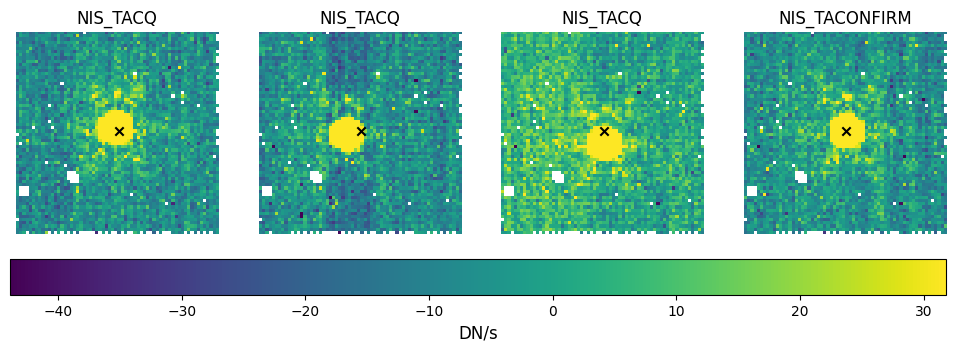

In [42]:
if (doviz & (len(tafiles) > 0)):
    # Prepare the figure
    fig, axs = plt.subplots(1, 4, figsize=(12, 3))
    for ii, ta_fn in enumerate(tafiles):
        # Plot the data
        with datamodels.open(ta_fn) as ta_dm:
            ta_im = ta_dm.data
            # Exclude outlier pixels
            sigma_clipped_data = sigma_clip(ta_im[0])
            imshape = ta_im[0].shape
            vmin = np.nanmin(sigma_clipped_data)
            vmax = np.nanmax(sigma_clipped_data)
            # normalize, adjusting the limits a bit
            norm = simple_norm(sigma_clipped_data, vmin=vmin - (0.5*abs(vmin)), vmax=vmax + (0.5*abs(vmax)))

            im = axs[ii].imshow(ta_im[0], origin='lower', norm=norm)
            units = ta_dm.meta.bunit_data
            axs[ii].set_title(ta_dm.meta.exposure.type)
            axs[ii].scatter(imshape[0]/2, imshape[1]/2, marker='x', color='k')

            axs[ii].set_axis_off()

    fig.subplots_adjust(bottom=.2)
    cbar_ax = fig.add_axes([0.12, 0.0, 0.78, 0.12])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(units, fontsize=12)

We can see that the source is being dithered in the first three images, and is nicely centered in the final image, as indicated by the black 'x' at the center of the array. The white pixels are those replaced by NaNs by the Detector1 pipeline due to saturation, outliers, or other data quality issues.

### Examine Detector1 products

We will begin by looking at the output of the first pipeline stage, the `rateints` files. As the 2D spectra over the duration of the time series will look very similar, we will only plot the first.

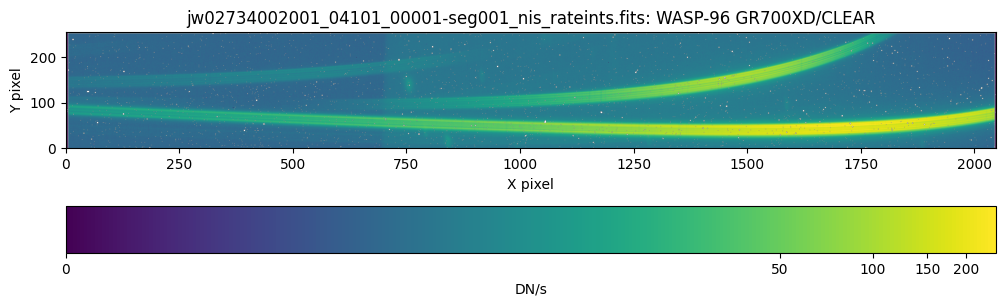

In [43]:
if doviz:
    display_soss_im(rateintsfiles[0])

We are displaying these images on a logarithmic scale to be able to see the features of both the cross-dispersed spectral traces and the background. To see them on a linear scale, pass the argument `lognormalize=False`. 

Orders 1, 2, and 3 are clearly visible in this image, along with some faint background sources. Order 1 extends across the full subarray and covers wavelengths from 0.9 $\mu m$ to 2.8 $\mu m$. The Order 2 trace, covering 0.6$ \mu m$ to 1.4$ \mu m$, overlaps with Order 1 at the longer-wavelength end of the traces. Order 3 peaks at ~0.6 $ \mu m$, though it is very faint.

For bright targets that would saturate the detector with the longer readout times of the SUBSTRIP256 subarray, users can elect to use the SUBSTRIP96 array. The 96-pixel vertical dimension of this subarray covers only the Order 1. For more information about the optics and spectral traces, see the [GR700X grism documentation](https://jwst-docs.stsci.edu/jwst-near-infrared-imager-and-slitless-spectrograph/niriss-instrumentation/niriss-gr700xd-grism).


Although we did not extract a spectrum from it, it is interesting to look at the F277W spectral image:

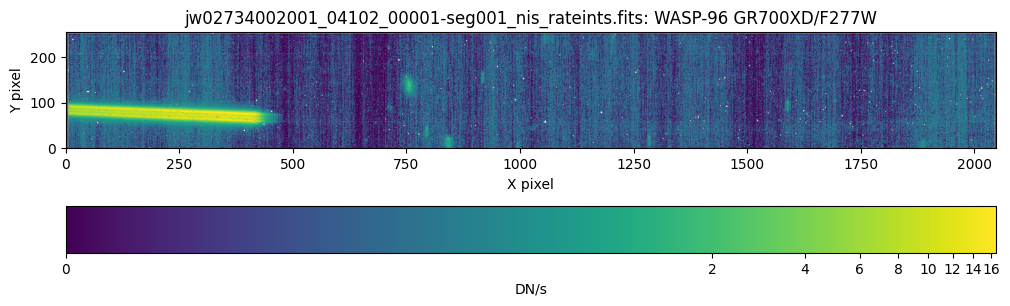

In [44]:
if (doviz & (len(f277wfiles) > 0)):
    display_soss_im(f277wfiles[0])

Compared to the CLEAR image above, we can clearly see that the Order 0 trace extends over only a small portion of the subarray, and Orders 2 and 3 are entirely absent. This is expected, because the left side of the subarray (in DMS orientation) corresponds to the longer wavelengths that SOSS is sensitive to, and the F277W filter covers only 2.413 $\mu m$ to 3.143 $\mu m$. This allows users to isolate the first order spectrum in the range where the first and second order overlap considerably. 

We can also see several potentially contaminating zeroth-order sources in the image (the Order 0 for our target does not fall on the detector). Characterizing these sources in the F277W image can allow users to model and remove them in the full wavelength coverage spectra, although this capability is not currently included in the pipeline. Best practices for obtaining an F277W exposure are included in the [SOSS Recommended Strategies](https://jwst-docs.stsci.edu/jwst-near-infrared-imager-and-slitless-spectrograph/niriss-observing-strategies/niriss-soss-recommended-strategies#NIRISSSOSSRecommendedStrategies-f277wAddinganoptionalF277Wexposuretoyourobservingprogram).

The 1/f noise (vertical striping) is also more apparent in this exposure because of the lower signal relative to the background.

### Examine Spec2 products

Next we will look at the outputs of the second pipeline stage: the calibrated `calints` images and the preliminary `x1dints` extracted spectra. For more information about the structure and contents of these data products, see the documentation about [x1d/x1dints](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html#extracted-1-d-spectroscopic-data-x1d-and-x1dints) and [calints](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html#calibrated-data-cal-and-calints) files.


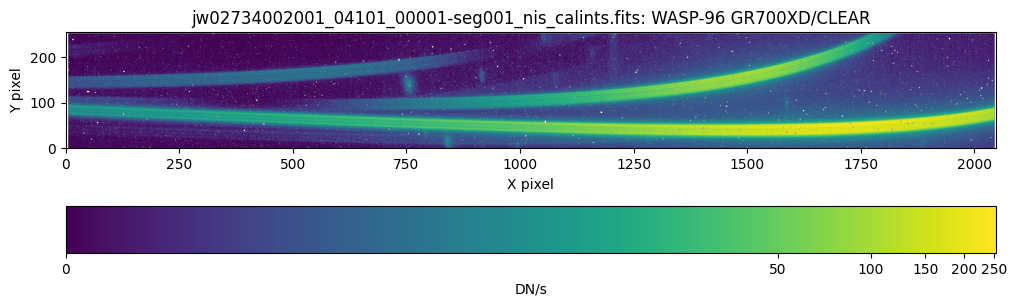

In [45]:
if doviz:
    display_soss_im(calintsfiles[0])

The SOSS sky background is characterized by a smooth rising gradient towards longer wavelengths, with a sharp discontinuity at around X=700 (corresponding to 2.1 $\mu m$ in Order 1) caused by the edges of the pick-off mirror (POM). The background varies with sky position and relative pointing due to the contribution of zodiacal light. Because of the variation in relative intensity on either side of the discontinuity, an empirical model cannot be simply linearly scaled to match a given observation. However, it is important to remove the background for most SOSS science use cases, so in the absence of a contemporaneous background exposure, the Spec2 `bkg_subtract` step finds the best match for each exposure from a library of empirical models scaled independently on either side of the discontinuity. 

We can see that the background is considerably lower in the background-subtracted `calints` image compared to the previous `rateints` image, and the discontinuity is not as prominent, though some structure remains. The NIRISS team intends to continue improving the background subtraction algorithm in the future.

Now, let's look at one of the extracted spectra. 

Order 1 dimensions: 96 integrations, 2048 wavelengths


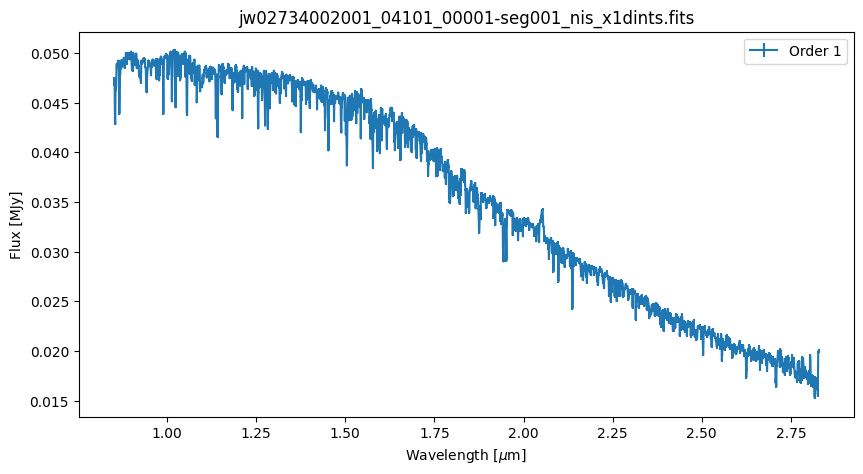

In [46]:
if doviz:
    display_spectrum(x1d_spec2files[0], order=1)

Note that not all of the "features" of this spectrum are absorption lines; many are due to bad pixels in the spectrum. As mentioned in the [TSO3 Pipeline](#7.-TSO3-Pipeline) section, there is an optional pixel replacement step that may reduce this type of noise.

This is the first integration of the time series, but we are especially interested in how the spectrum changes over the duration of the observations. Let's look at the spectrum as a function of both wavelength and time:

Order 1 dimensions: 280 integrations, 2048 wavelengths


Order 2 dimensions: 280 integrations, 1783 wavelengths


/tmp/ipykernel_3291/2999729553.py:30: RuntimeWarning: Mean of empty slice
  first100 = np.nanmean(flux[:100, :], axis=0)


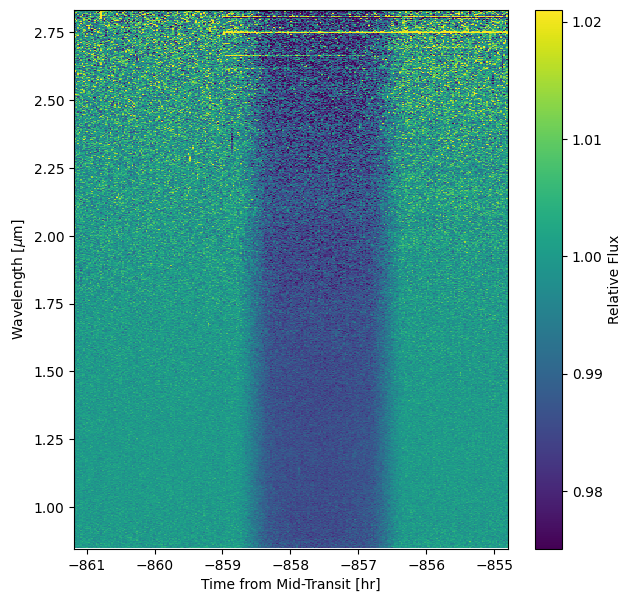

In [47]:
if doviz:
    spectrum_timeseries(x1d_spec2files)

In this plot, the flux at each wavelength is normalized so that the decrease in flux caused by the transiting exoplanet is emphasized. 

If we pass the argument `normalize=False` to the plotting function, the transit is much less obvious but we can see some interesting spectral features, as well as how the flux decreases at longer wavelengths.

Order 1 dimensions: 280 integrations, 2048 wavelengths


Order 2 dimensions: 280 integrations, 1783 wavelengths


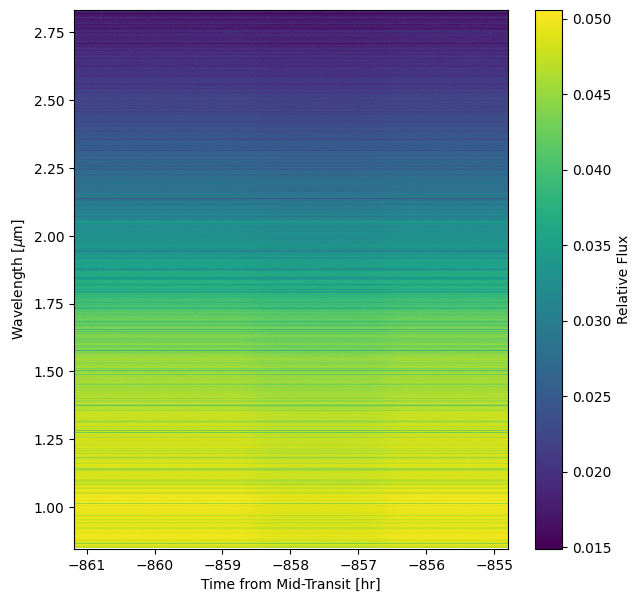

In [48]:
if doviz:
    spectrum_timeseries(x1d_spec2files, normalize=False)

### Examine TSO3 products

Lastly, we will examine the products of the third and final pipeline stage: the final `x1dints` spectra and the white light (`whtlt`) curve for orders 1 and 2.

Order 1 dimensions: 280 integrations, 2048 wavelengths


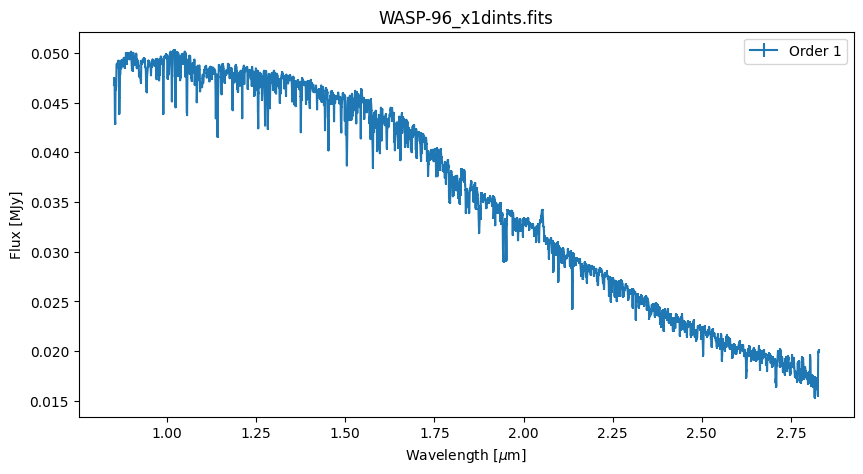

In [49]:
if doviz:
    display_spectrum(x1d_tso3file, order=1)

Order 2 dimensions: 280 integrations, 1783 wavelengths


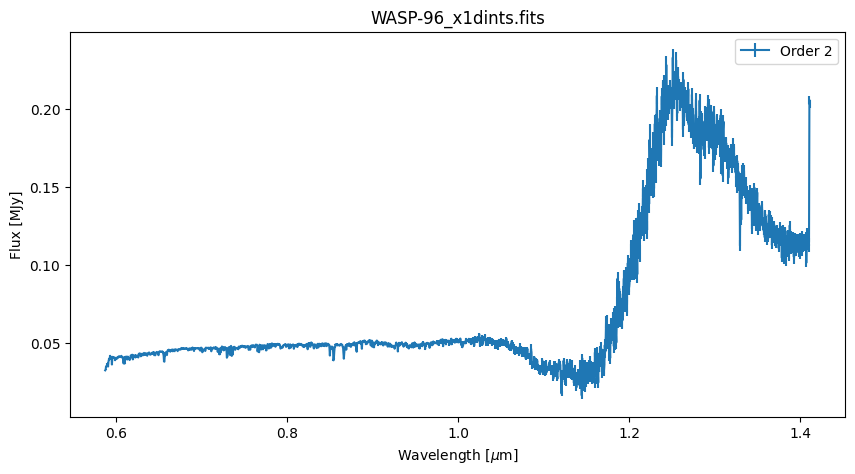

In [50]:
if doviz:
    display_spectrum(x1d_tso3file, order=2)

By eye, there is not much difference apparent between the Stage 2 x1dints files and the Stage 3 x1dints files; the main difference is that the outlier detection step has now been run. However, it is worth noting that in Order 2, measurements beyond ~1 $\mu m$ are not reliable due to contamination from Order 1.

We can also make the 2d transit plot again, using the final extracted spectrum:

Order 1 dimensions: 280 integrations, 2048 wavelengths


Order 2 dimensions: 280 integrations, 1783 wavelengths


/tmp/ipykernel_3291/2999729553.py:30: RuntimeWarning: Mean of empty slice
  first100 = np.nanmean(flux[:100, :], axis=0)


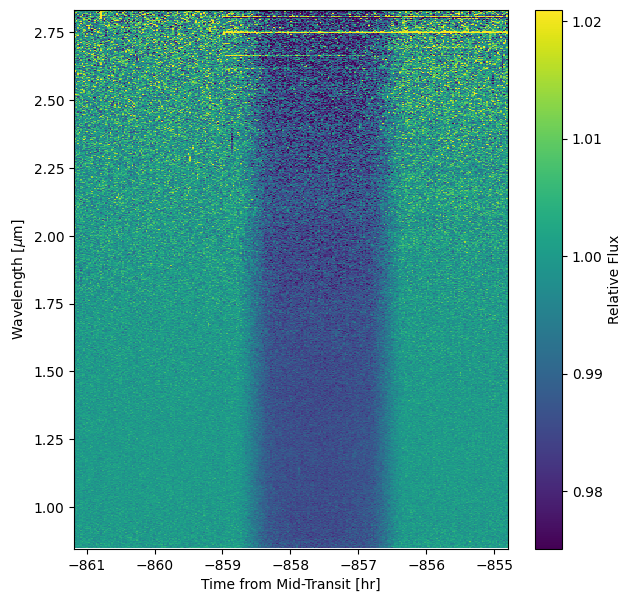

In [51]:
if doviz:
    spectrum_timeseries(x1d_tso3file)

Lastly, let's look at the white light curve. In this file, the flux at each wavelength has been summed to give us a single value at each timestamp. 

We will plot the white light curve for orders 1 and 2, along with a simple transit model using the `batman` package ([Kreidberg 2015](https://ui.adsabs.harvard.edu/abs/2015PASP..127.1161K/abstract)). We adopt all of our planetary parameters from [McGruder et al. 2023](https://ui.adsabs.harvard.edu/abs/2023ApJ...944L..56M/abstract), except for the ratio of the planet radius to the stellar radius ($R_{p}/R_{*}$), which is from [Kokori et al. 2023](https://ui.adsabs.harvard.edu/abs/2023ApJS..265....4K/abstract).

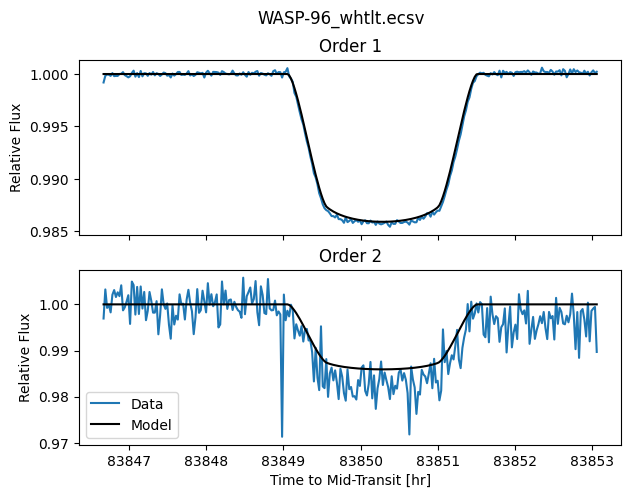

In [52]:
if doviz:
    # Set up the model parameters
    params = batman.TransitParams()
    params.t0 = 2456258.06272 - 2400000.5       # time of inferior conjunction
    params.per = 3.4252567                        # orbital period
    params.rp = 0.1175                            # planet radius (in units of stellar radii)
    params.a = 9.13                               # semi-major axis (in units of stellar radii)
    params.inc = 85.45                            # orbital inclination (in degrees)
    params.ecc = 0.                               # eccentricity
    params.w = 90.                                # longitude of periastron (in degrees)
    params.u = [0.16, 0.26]                       # limb darkening coefficients [u1, u2]
    params.limb_dark = "quadratic"                # limb darkening model

    # Display the light curves and models
    display_lightcurve(whtltfile, order=[1, 2], modelparams=params)

Since the model parameters were derived from a different reduction that used the same data, it makes sense that this model looks like a pretty good fit to the data by eye. Further model fitting is beyond the scope of this notebook, but can also be done using `batman` or a variety of other open-source software packages.

<hr style="border:1px solid gray"> </hr>

<img style="float: center;" src="https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_footer.png" alt="stsci_logo" width="200px"/> 